# Choose a variational family

Use {class}`~liesel.optim.VDist` for one group of target parameters and
{class}`~liesel.optim.CompositeVDist` for independent groups. Both build the
variational model and map draws back to the target's names and shapes.

Start with the fitting workflow in {doc}`variational-inference`. Here we compare
Gaussian families, {ref}`supply your own distribution <vi-custom-distribution>`,
then build an {ref}`advanced custom graph <vi-custom-graph>`.

## Define the target

This regression has correlated intercept and slope parameters on the real line.
The observation scale is known.

In [1]:
import jax
import jax.numpy as jnp
import optax
import pandas as pd
import tensorflow_probability.substrates.jax.distributions as tfd

import liesel.model as lsl
import liesel.optim as opt

alpha = lsl.Var.new_param(0.0, dist=lsl.Dist(tfd.Normal, 0.0, 2.0), name="alpha")
beta = lsl.Var.new_param(0.0, dist=lsl.Dist(tfd.Normal, 0.0, 2.0), name="beta")

x = lsl.Var.new_value(jnp.arange(5.0), name="x")
mean = lsl.Var.new_calc(
    lambda a, b, x: a + b * x,
    alpha,
    beta,
    x,
    name="mean",
)

y = lsl.Var.new_obs(
    jnp.array([1.1, 1.7, 3.0, 3.8, 5.2]),
    dist=lsl.Dist(tfd.Normal, mean, 0.5),
    name="y",
)
model = lsl.Model(y)

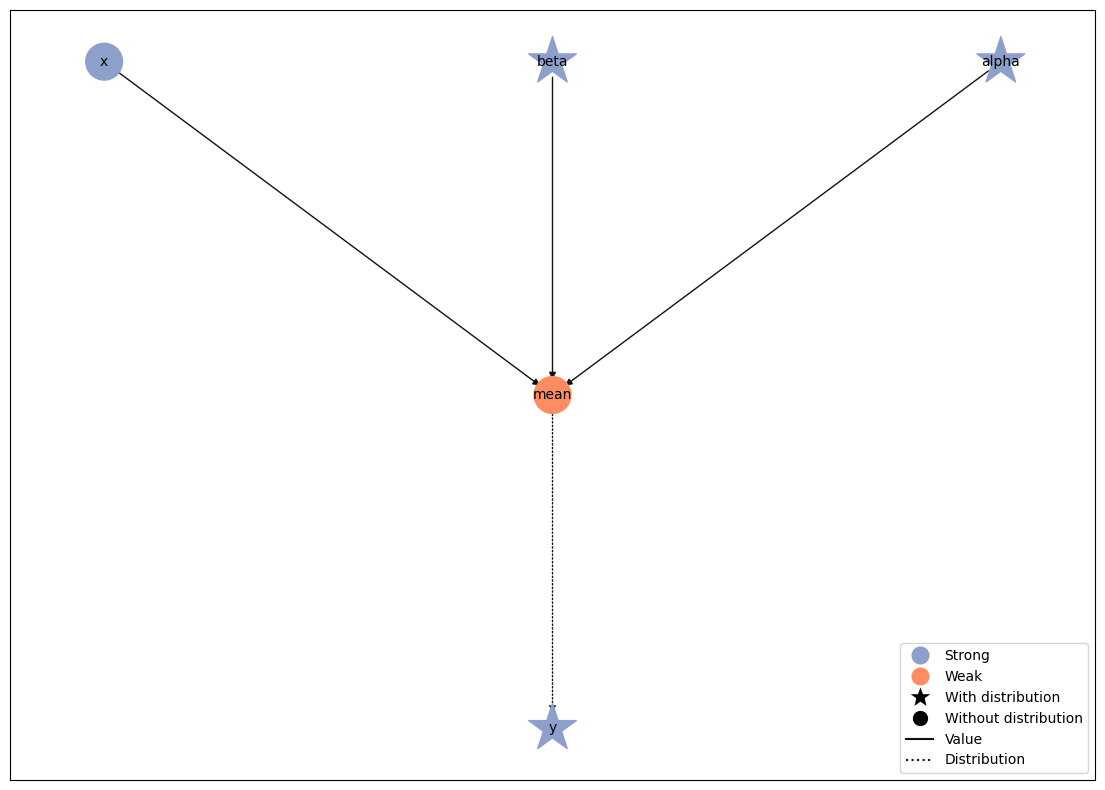

In [2]:
model.plot()

(vi-gaussian-shortcuts)=

## Use Gaussian loss shortcuts

For a Gaussian over **all** target parameters, these shortcuts return a ready
loss. They build a {class}`VDist <liesel.optim.VDist>` internally; no separate {meth}`build() <liesel.optim.VDist.build>` call is needed.

Use {meth}`~liesel.optim.NegElboLoss.mvn_diag` for independent components, each
with its own learned mean and standard deviation:

In [3]:
diagonal_loss = opt.NegElboLoss.mvn_diag(
    model,
    scale_diag=0.5,
    nsamples=16,
    scale=True,
)

Use {meth}`~liesel.optim.NegElboLoss.mvn_tril` to learn correlations as well:

In [4]:
correlated_loss = opt.NegElboLoss.mvn_tril(
    model,
    scale_tril=0.5,
    nsamples=16,
    scale=True,
)

Both use current target values as initial means, with SD 0.5. The diagonal family keeps
components independent; the dense family can learn correlations. Its Cholesky
factor requires quadratic storage rather than linear storage for diagonal scales.
`scale=True` normalizes the loss, independently of the Gaussian scale.

Pass either loss to {class}`LieselVI <liesel.optim.LieselVI>` as in {doc}`variational-inference`. The next
sections show how to select parameters and choose your own blocks.

## Build one Gaussian block

{class}`VDist <liesel.optim.VDist>` selects named target parameters, including vectors and matrices. Use
unconstrained names for transformed parameters. Its Gaussian constructors return
the helper; {meth}`build() <liesel.optim.VDist.build>` creates the underlying model in `.q`.

Use {meth}`.mvn_diag() <liesel.optim.VDist.mvn_diag>` for independent components:

In [5]:
diagonal = opt.VDist(["alpha", "beta"], model).mvn_diag(scale_diag=0.5).build()

Use {meth}`.mvn_tril() <liesel.optim.VDist.mvn_tril>` to learn correlations within the block:

In [6]:
dense = opt.VDist(["alpha", "beta"], model).mvn_tril(scale_tril=0.5).build()

`scale_tril` is a lower Cholesky factor, with covariance
`scale_tril @ scale_tril.T`. A scalar starts it at that multiple of the identity.
Initial means default to current target values; a scalar `loc` ties their means,
so supply a vector for distinct values. See {ref}`vi-initial-scale` for scale choices.

The helper's `parameters` lists the variational names the optimizer adjusts:

In [7]:
dense.parameters

['(alpha|beta)_loc', 'h((alpha|beta)_scale_tril)']

Sampling restores target names and shapes:

In [8]:
initial_draws = dense.sample(4, seed=jax.random.key(40))

In [9]:
pd.DataFrame(initial_draws)

,alpha,beta
0,0.256495,0.122035
1,0.141059,1.032080
2,0.495520,0.446619
3,0.384071,-0.655034


These are initial draws. Fitted draws use {meth}`loss.approximate_joint_posterior(result) <liesel.optim.NegElboLoss.approximate_joint_posterior>`.

(vi-custom-distribution)=

## Use your own distribution

{meth}`VDist.init() <liesel.optim.VDist.init>` accepts any
{class}`~liesel.model.Dist` over the block's parameters, so a few Liesel
variables define the family: heavier tails, other shapes, or shared and
transformed inputs. Here each parameter gets a logistic distribution, which has
heavier tails than a normal, with its own learned location and scale:

In [10]:
q_loc = lsl.Var.new_param(jnp.zeros(2), name="q_loc")
q_log_scale = lsl.Var.new_param(jnp.log(jnp.full(2, 0.5)), name="q_log_scale")
q_scale = lsl.Var.new_calc(jnp.exp, q_log_scale, name="q_scale")

logistic = lsl.Dist(tfd.Logistic, loc=q_loc, scale=q_scale)
heavy_tailed = opt.VDist(["alpha", "beta"], model).init(logistic).build()

The distribution describes the block's flattened parameters: names in sorted
order, each flattened, so `alpha` then `beta` here. Its draws must be fully
reparameterized. Mark the inputs to optimize as parameters; computed inputs such
as `q_scale` follow them. These are the names the optimizer adjusts:

In [11]:
heavy_tailed.parameters

['q_loc', 'q_log_scale']

The result is an ordinary block: combine it with other blocks or connect it to
a loss as shown below.

## Combine independent blocks

Choose a distribution on each {class}`VDist <liesel.optim.VDist>`, then combine the initialized blocks.
They must share one target model, with no target name appearing in two blocks:

In [12]:
alpha_block = opt.VDist(["alpha"], model).mvn_diag(scale_diag=0.5)
beta_block = opt.VDist(["beta"], model).mvn_diag(scale_diag=0.2)
blocked = opt.CompositeVDist(alpha_block, beta_block).build()

This family keeps `alpha` and `beta` independent. For larger models, put related
parameters in an `mvn_tril` block to learn correlations within that group;
different blocks remain independent. This restriction can change fitted marginal
variances as well as removing cross-block dependence.

Omitted target parameters stay fixed at current values. To get one dense block
per target parameter automatically, use {meth}`~liesel.optim.NegElboLoss.mvn_blocked`.

## Connect a family to the loss

{meth}`~liesel.optim.NegElboLoss.from_vdist` accepts either built helper:

In [13]:
dense_loss = opt.NegElboLoss.from_vdist(dense, nsamples=16, scale=True)
blocked_loss = opt.NegElboLoss.from_vdist(blocked, nsamples=16, scale=True)
heavy_tailed_loss = opt.NegElboLoss.from_vdist(heavy_tailed, nsamples=16, scale=True)

Pass either loss to `LieselVI(model, ...)`. Fitting does not update the helper's
model values: sample the fitted posterior through
{meth}`loss.approximate_joint_posterior(result) <liesel.optim.NegElboLoss.approximate_joint_posterior>`, or supply `at_position` to the helper's
`sample` method.

For conditional dependencies between parameters, define a graph below.

(vi-custom-graph)=

## Advanced: custom graphs

An ordinary Liesel {class}`~liesel.model.Model` lets you define conditional draws
and share variational parameters. Here `alpha` is drawn first; `beta` then has mean
`beta_loc + dependence * alpha`. Observed variables in `q` represent draws, while
strong parameters are the inputs to optimize.

In [14]:
alpha_loc = lsl.Var.new_param(
    0.0,
    dist=lsl.Dist(tfd.Normal, 0.0, 1.0),
    name="alpha_loc",
)
beta_loc = lsl.Var.new_param(0.0, name="beta_loc")
dependence = lsl.Var.new_param(0.0, name="dependence")

log_scale = lsl.Var.new_param(-0.7, name="log_scale")
scale = lsl.Var.new_calc(jnp.exp, log_scale, name="scale")

q_alpha = lsl.Var.new_obs(
    0.0, dist=lsl.Dist(tfd.Normal, alpha_loc, scale), name="alpha"
)

beta_mean = lsl.Var.new_calc(
    lambda loc, coefficient, parent: loc + coefficient * parent,
    beta_loc,
    dependence,
    q_alpha,
    name="beta_mean",
)
q_beta = lsl.Var.new_obs(
    0.0, dist=lsl.Dist(tfd.Normal, beta_mean, scale), name="beta"
)
q = lsl.Model(q_beta)

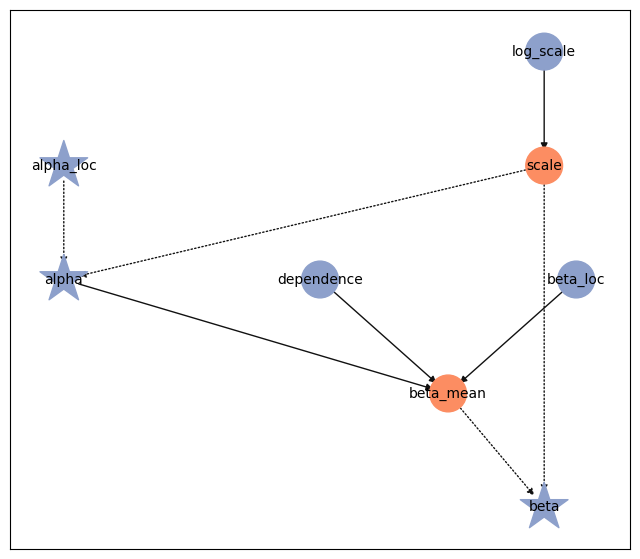

In [15]:
q.plot(width=8, height=7, legend=False)

Optimize strong inputs such as `log_scale`; derived scales and means remain
computed variables. Every sampled distribution must belong to an observed `q`
variable and support fully reparameterized draws. See
{class}`~liesel.optim.NegElboLoss` for custom-family requirements.

The prior on `alpha_loc` is ignored by default; target priors on `alpha` and
`beta` remain included. See {ref}`vi-q-prior-penalties` below.

### Fit and sample

The observed names and shapes in `q` match the target parameters, so no explicit
mapping is needed. Pass the same target model to the loss and {class}`LieselVI <liesel.optim.LieselVI>`:

In [16]:
loss = opt.NegElboLoss(model, q, nsamples=16, scale=True)

result = opt.LieselVI(
    model,
    loss=loss,
    optimizers=optax.adam(0.01),
    loss_monitor=opt.EmaTrainLossMonitor(effective_window=20.0),
    stopper=opt.Stopper(epochs=500, patience=500),
    seed=42,
    show_progress=False,
).fit()

posterior = loss.approximate_joint_posterior(result)
draws = posterior.sample(1_000, seed=jax.random.key(43))

liesel.optim.engine - INFO - Initializing optimization at epoch 0


In [17]:
pd.DataFrame(draws).agg(["mean", "std"]).round(3)

,alpha,beta
mean,0.938,1.005
std,0.124,0.125


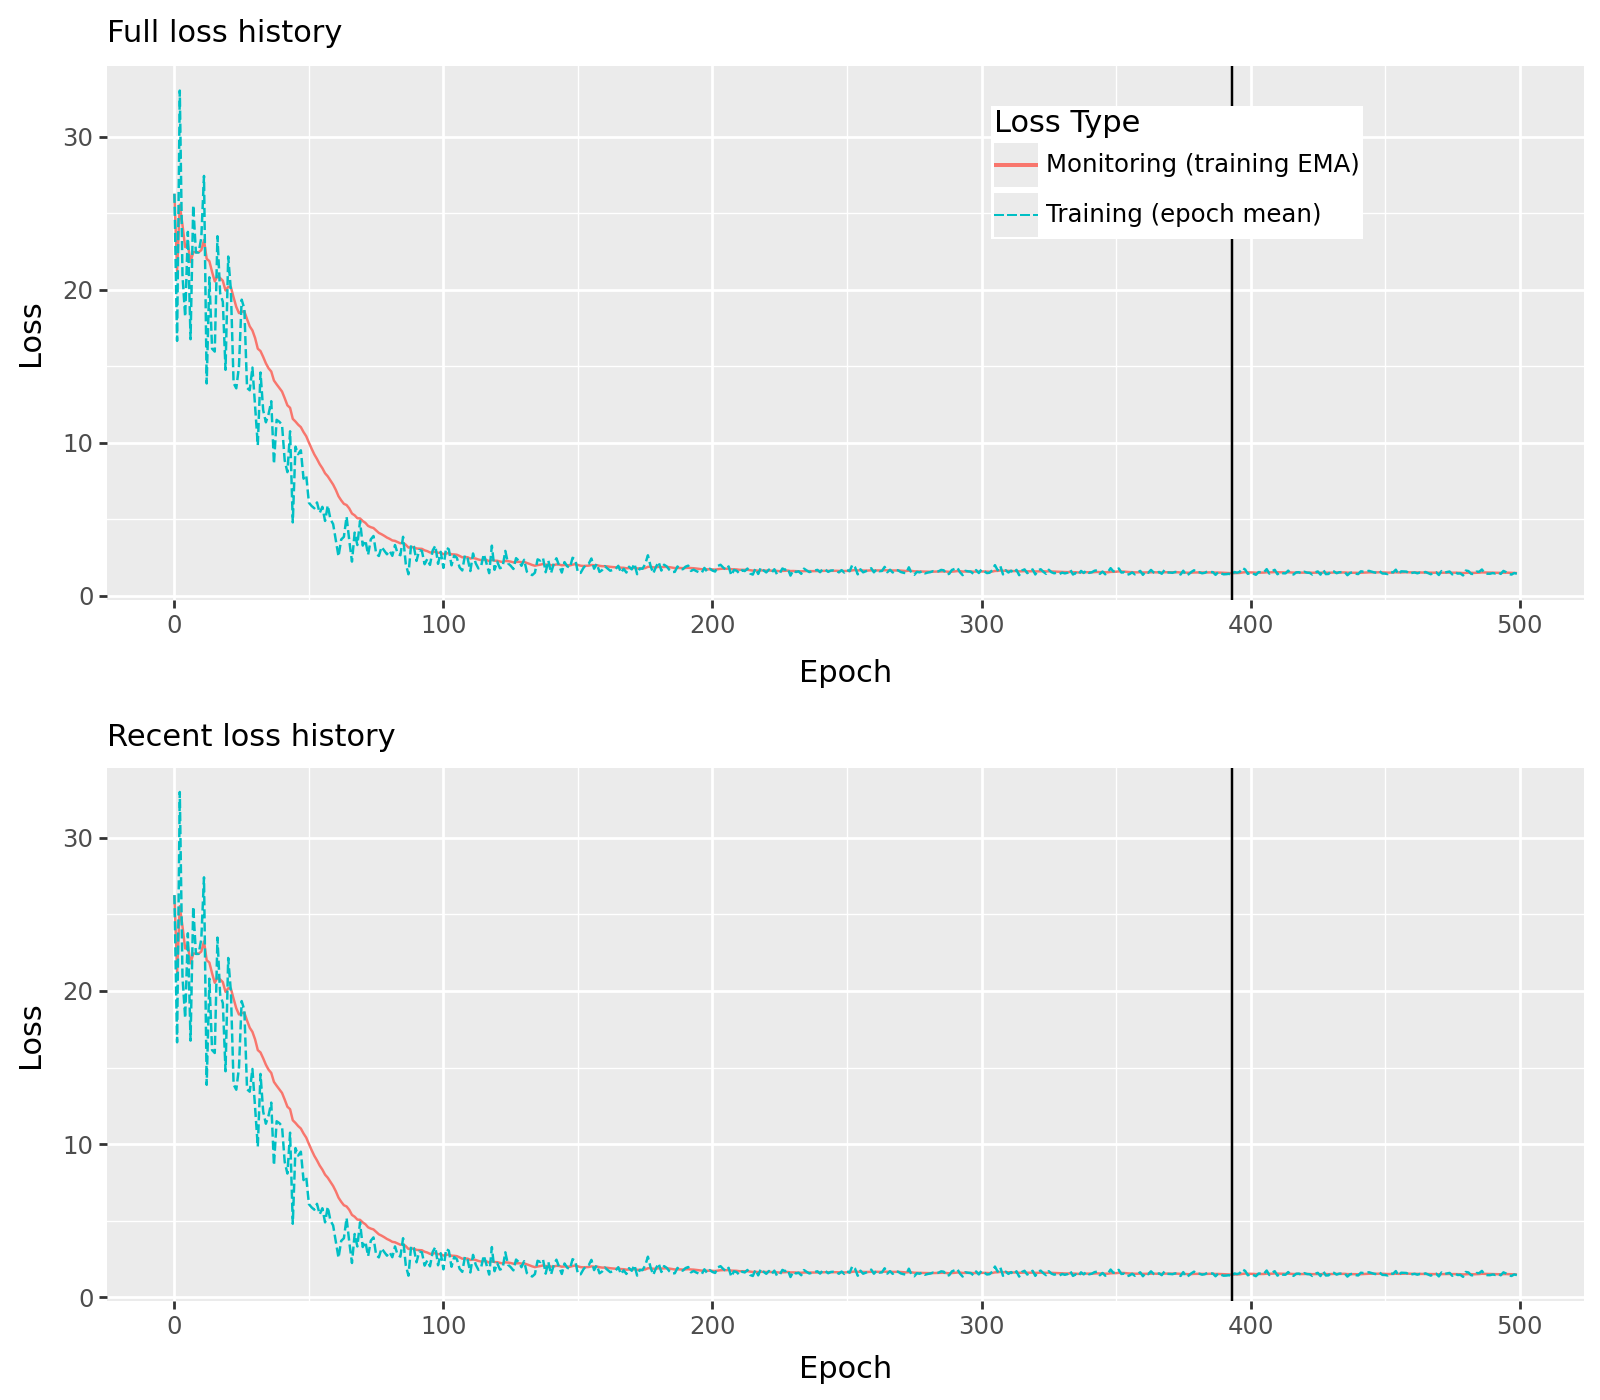

In [18]:
result.plot_loss_overview()

Both draws share one conditional scale here; use separate scale parameters if
that restriction is unsuitable. `entropy="auto"` averages conditional entropies
over sampled parents. For monitoring and fit checks, see {doc}`variational-inference`.

(vi-q-prior-penalties)=

### Choose q-parameter penalties

The ordinary ELBO includes target likelihood, target priors, and variational
entropy. A prior on an optimized `q` parameter such as `alpha_loc` is different:
`regularize_q_prior=True` adds it as a penalty and changes the objective.
The default is `False`; target priors remain included either way. Built-in
Gaussian families have no q-parameter priors.

Compare the objectives at the same parameters and random draws:

In [19]:
regularized_loss = opt.NegElboLoss(model, q, nsamples=16, regularize_q_prior=True)

params = result.position_final
key = jax.random.key(45)
elbo = loss.estimate_elbo(params, key)
regularized = regularized_loss.estimate_elbo(params, key)

In [20]:
pd.DataFrame(
    {"Value": [elbo, regularized, regularized - elbo]},
    index=["Ordinary ELBO", "Regularized objective", "Added q-prior term"],
).astype(float).round(3)

,Value
Ordinary ELBO,-7.645
Regularized objective,-9.003
Added q-prior term,-1.358


The difference is the log prior at the fitted `alpha_loc`. To optimize this
penalized objective, pass `regularized_loss` to {class}`LieselVI <liesel.optim.LieselVI>`; wrapper flags do not
modify an explicit loss.

### Map names and shapes

Supply `q_to_p` for structural renaming or reshaping of one draw. The mapping
must be one-to-one and density-preserving: no Jacobian is added for it. Put
nonlinear transforms inside `q`, including their Jacobians in its density.
{class}`VDist <liesel.optim.VDist>` supplies its unflattening mapping automatically.

Custom joint densities and auxiliary variables require care; see the
{class}`~liesel.optim.NegElboLoss` contract before defining them.

Custom transformed families remain subject to the TFP/JAX cache limitation in
[issue #418](https://github.com/liesel-devs/liesel/issues/418).

## Use another objective

For a different objective, supply a {class}`~liesel.optim.Loss` to
{class}`~liesel.optim.OptimEngine`. The loss owns sampling, density calculations,
and the mapping from optimizer keys to values; the engine handles optimizer
steps, batches, and monitoring. {class}`~liesel.optim.LossMixin` provides gradient
helpers. Implement `loss_train_batched` and, for full-data monitoring, `loss_train`
according to their documented return contracts.